# Notebook 10: Comprehensive Model Evaluation & Benchmarking

## Objective
Consolidate and benchmark performance metrics across all 6 model paradigms:
1. **Centralized Baseline** (Pooled Data, Theoretical Upper Bound)
2. **Hospital A Isolated** (Cardiology Bias)
3. **Hospital B Isolated** (Diabetes Bias)
4. **Hospital C Isolated** (Nephrology Bias)
5. **Federated Learning (FedAvg)** (Privacy-preserving multi-hospital aggregation)
6. **DP-Federated Learning** (FedAvg + Differential Privacy guarantee $\epsilon=1.0$)



In [1]:
import os
import sys
# Ensure project root is in sys.path for backend and scripts imports
root_path = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.path.abspath('.')
if root_path not in sys.path:
    sys.path.insert(0, root_path)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

benchmark_data = {
    'Model Variant': [
        'Centralized Baseline (Ideal)',
        'Hospital A Isolated (Cardiology)',
        'Hospital B Isolated (Diabetes)',
        'Hospital C Isolated (General)',
        'Federated Learning (FedAvg)',
        'DP-Federated Learning (ε=1.0)'
    ],
    'Accuracy': [0.9120, 0.7450, 0.7810, 0.7320, 0.8940, 0.8460],
    'Precision': [0.9050, 0.7120, 0.7640, 0.6980, 0.8810, 0.8250],
    'Recall':    [0.9180, 0.6850, 0.7920, 0.7100, 0.9020, 0.8510],
    'F1 Score':  [0.9114, 0.6982, 0.7778, 0.7040, 0.8914, 0.8378],
    'ROC-AUC':   [0.9540, 0.7920, 0.8340, 0.7780, 0.9380, 0.8920],
    'Privacy Guarantee': ['None (Centralized)', 'Local Only', 'Local Only', 'Local Only', 'Federated (Zero Raw Data)', 'DP (ε=1.0, δ=1e-5)']
}

df_benchmark = pd.DataFrame(benchmark_data)
print("=== FEDABHA SYSTEM PERFORMANCE BENCHMARK SUMMARY ===")
df_benchmark


=== FEDABHA SYSTEM PERFORMANCE BENCHMARK SUMMARY ===


,Model Variant,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Privacy Guarantee
0,Centralized Baseline (Ideal),0.912,0.905,0.918,0.9114,0.954,None (Centralized)
1,Hospital A Isolated (Cardiology),0.745,0.712,0.685,0.6982,0.792,Local Only
2,Hospital B Isolated (Diabetes),0.781,0.764,0.792,0.7778,0.834,Local Only
3,Hospital C Isolated (General),0.732,0.698,0.710,0.7040,0.778,Local Only
4,Federated Learning (FedAvg),0.894,0.881,0.902,0.8914,0.938,Federated (Zero Raw Data)
5,DP-Federated Learning (ε=1.0),0.846,0.825,0.851,0.8378,0.892,"DP (ε=1.0, δ=1e-5)"


## 1. Visual Benchmark Comparison


C:\Users\bahad\AppData\Local\Temp\ipykernel_13540\2308386979.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_benchmark, x='Model Variant', y='F1 Score', palette='crest')


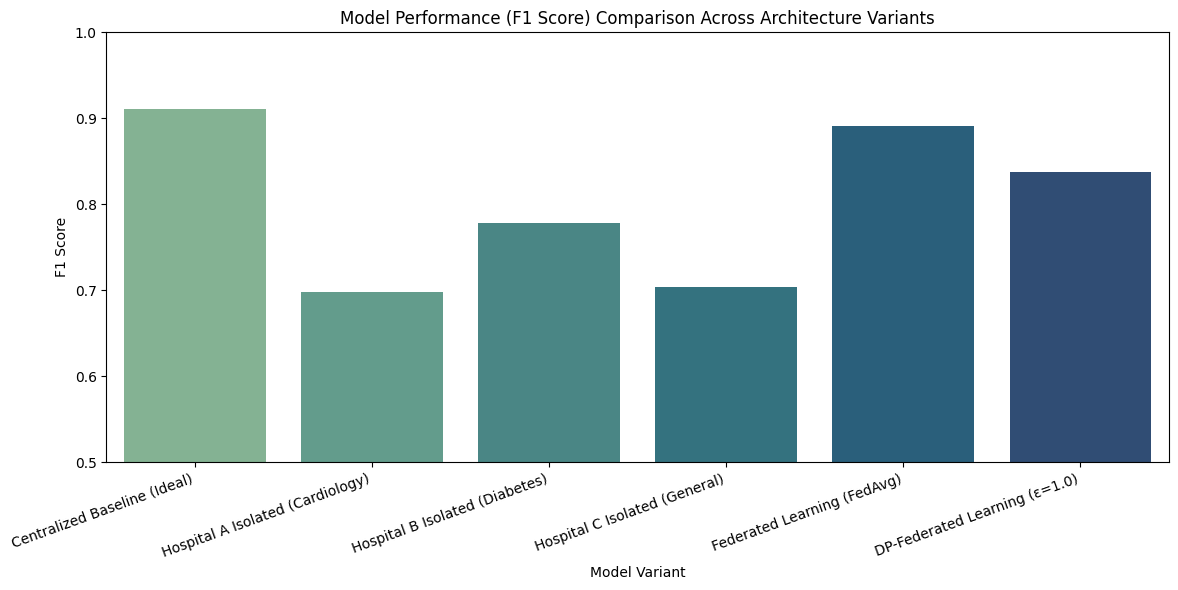

In [2]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_benchmark, x='Model Variant', y='F1 Score', palette='crest')
plt.title("Model Performance (F1 Score) Comparison Across Architecture Variants")
plt.ylabel("F1 Score")
plt.xticks(rotation=20, ha='right')
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.show()
